Looking into full regeneration dataset to help guide my coding

In [4]:
file_name = "/home/mcb/users/msandl4/scTimeBench/data/artista/Regeneration_subset_hvg2.h5ad"


In [5]:
import scanpy as sc
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
import phate
import sys
from tqdm import tqdm
import seaborn as sns 
# Import the modules themselves
import torchcfm.conditional_flow_matching as cfm
import torchcfm.models as models
import torchcfm.utils as utils
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [6]:
adata = sc.read_h5ad(file_name)
adata

AnnData object with n_obs × n_vars = 13314 × 2078
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'n_genes', 'timepoint'
    var: 'Gene', 'analog_gene', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'hvg'
    obsm: 'X_pca', 'X_spatial', 'spatial'
    layers: 'counts'

In [9]:
adata.obs["D_V"].unique()

['V', 'D']
Categories (2, object): ['D', 'V']

In [11]:
adata.obs["spatial_leiden_e30_s8"].unique()

['0', '5', '8', '6', '9', ..., '4', '7', '1', '11', '10']
Length: 12
Categories (12, object): ['0', '1', '2', '3', ..., '8', '9', '10', '11']

In [16]:
time_map = {
    '2DPI': 2,
    '5DPI': 5,
    '10DPI': 10,
    '15DPI': 15,
    '20DPI': 20
}

# Apply the mapping to the observations
adata.obs["timepoints"] = adata.obs["timepoint"].map(time_map).astype(int)


In [18]:
adata.obs["timepoints"].unique()

array([ 2,  5, 10, 15, 20])

/tmp/ipykernel_1729936/2752483047.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters))


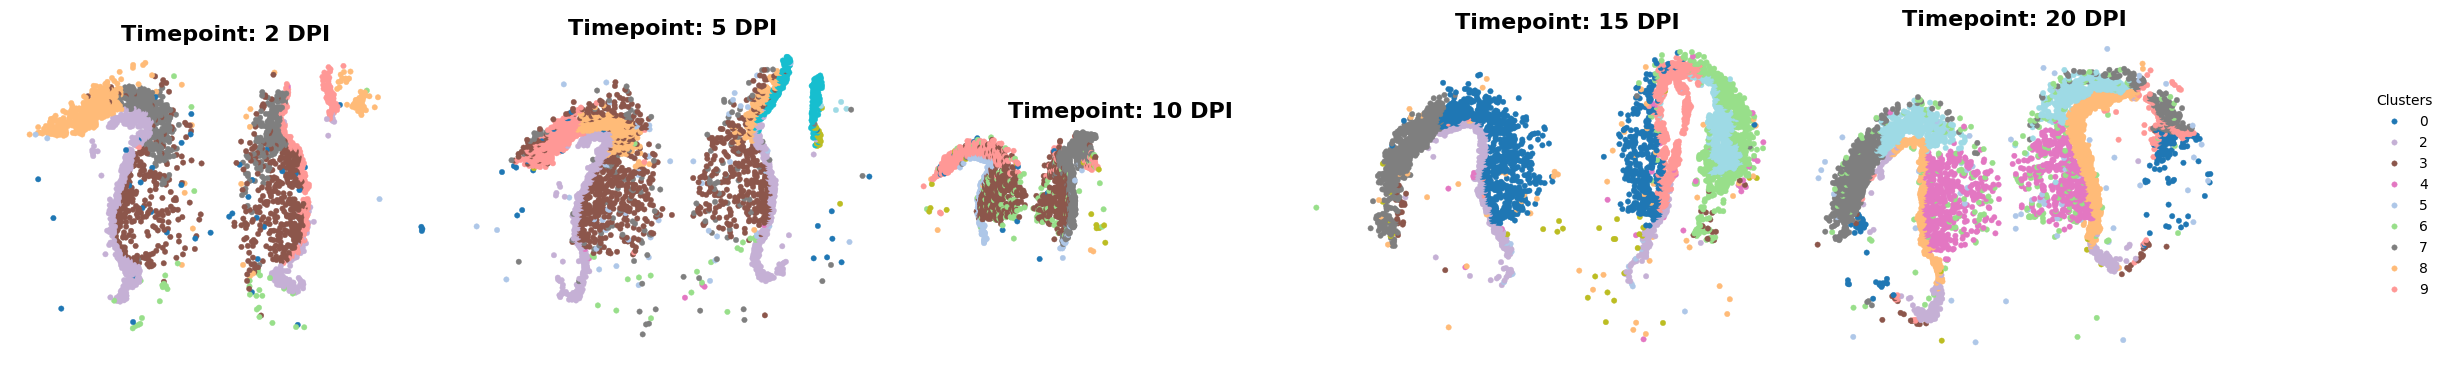

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the grid
tps = sorted(adata.obs['timepoints'].unique())
clusters = adata.obs["spatial_leiden_e30_s8"].unique()
cmap = plt.cm.get_cmap("tab20", len(clusters))

# Build mapping
color_map = {cl: cmap(i) for i, cl in enumerate(clusters)}

ncols = 5
nrows = (len(tps) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

# 2. Plot each slide
for i, tp in enumerate(tps):
    # Slice the adata for the specific timepoint
    data = adata[adata.obs['timepoints'] == tp].copy()
    
    sns.scatterplot(
        x=data.obsm['spatial'][:, 0], 
        y=data.obsm['spatial'][:, 1], 
        hue=data.obs["spatial_leiden_e30_s8"], # FIX: Use 'data' not 'adata'
        palette=color_map,
        ax=axes[i], 
        s=15, 
        edgecolor=None,
        legend=(i == 0) # Temporary legend for the first plot to grab handles
    )
    
    axes[i].set_title(f"Timepoint: {tp} DPI", fontsize=16, fontweight='bold')
    axes[i].set_aspect('equal')
    axes[i].invert_yaxis() # Often needed for spatial data to match physical tissue orientation
    axes[i].axis('off')

# 3. Create a Single Global Legend
# Grab handles and labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove() # Remove the local legend from the first subplot

fig.legend(
    handles, labels, 
    loc='center right', 
    title="Clusters", 
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

# 4. Cleanup and show
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout to make room for the legend on the right
plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.savefig("spatial_coordinates_axolotl.jpg", dpi=300)
plt.show()